# Implement simple variant of self-attention

In [10]:
import re
import torch

Let's assume we have the following input sentence:

```python
text = "Your journey starts with one step"
```
Let's assume tokens have been already identified (one word = one token):

```python
tokens = ['Your', 'journey', 'starts', 'with', 'one', 'step']
```

A vocabulary has been crated and token ids have been assigned to each token:

```python
vocab = {token: idx for idx, token in enumerate(tokens)}
```

In [37]:
tokens = ['Your', 'journey', 'starts', 'with', 'one', 'step']
vocab = {token: idx for idx, token in enumerate(tokens)}
print(vocab)

{'Your': 0, 'journey': 1, 'starts': 2, 'with': 3, 'one': 4, 'step': 5}


Given our vocabulary:

```python 
{'Your': 0, 'journey': 1, 'starts': 2, 'with': 3, 'one': 4, 'step': 5}
```
we have performed token embeddings using 3-dimension vectors:

```

0 -->   [0.43, 0.15, 0.89]  # Your     (x^1)
1 -->   [0.55, 0.87, 0.66]  # journey  (x^2)
2 -->   [0.57, 0.85, 0.64]  # starts   (x^3)
3 -->   [0.22, 0.58, 0.33]  # with     (x^4)
4 -->   [0.77, 0.25, 0.10]  # one      (x^5)   
5 -->   [0.05, 0.80, 0.55]  # step     (x^6)


```

In [ ]:
# import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.43, 0.15, 0.89], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

In [14]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

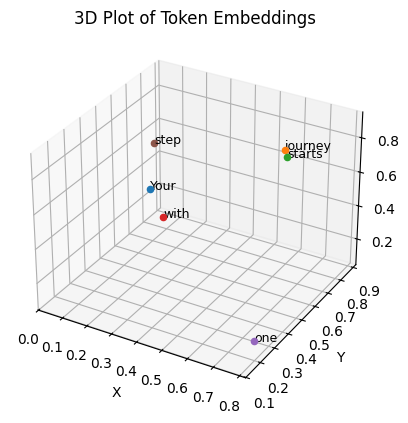

In [16]:
tokens = ['Your', 'journey', 'starts', 'with', 'one', 'step']

x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for x, y, z, token in zip(x_coords, y_coords, z_coords, tokens):
    ax.scatter(x, y, z)
    ax.text(x, y, z, token, fontsize=9)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.set_title('3D Plot of Token Embeddings')
plt.show()

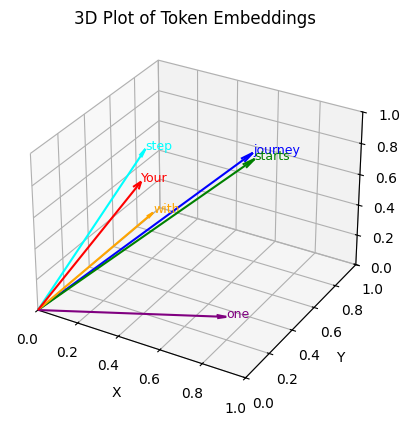

In [18]:
tokens = ['Your', 'journey', 'starts', 'with', 'one', 'step']

x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan']

for x, y, z, token, color in zip(x_coords, y_coords, z_coords, tokens, colors):
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, token, fontsize=9, color=color)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

ax.set_title('3D Plot of Token Embeddings')
plt.show()

We need to determine context vector for each tokem ...

> X is input vector [x<sub>1</sub>, x<sub>2</sub>, x<sub>3</sub>, ..., x<sub>n</sub>]

> Z is context vector [z<sub>1</sub>, 2<sub>n</sub>, 3<sub>n</sub>, ..., z<sub>n</sub>]

This is a three steps process:

1. Compute **attention scores**: (dot products between the inputs)

2. Compute **attention weights**: (normalization of attention scores)

3. Compute **context vectors**: (weighted sum over the inputs)


### Step 1 - Computing attention scores

In order to calculate Z, as a first step we need to determine the **attention scores** w<sub>ij</sub> values:

We start from token x<sub>2</sub> = "journey" 


|   Inputs ->   | Your <br>(x<sub>1</sub>)| journey <br>(x<sub>2</sub>)| starts <br>(x<sub>3</sub>)| ... | step <br>(x<sub>t</sub>) |
|:-----|:----:|:-------:|:------:|:----:|:----:|
| Your (x<sub>1</sub>) | ... | ... | ... |... | ... |
| journey (x<sub>2</sub>) | w<sub>21</sub> | w<sub>22</sub> | w<sub>23</sub> | ... | w<sub>26</sub> |
| starts (x<sub>3</sub>) | ... | ... | ... |... | ... |
| with (x<sub>4</sub>) | ... | ... | ... |... | ... |
| one (x<sub>5</sub>) | ... | ... | ... |... | ... |
| step (x<sub>6</sub>) | ... | ... | ... |... | ... |


we use dot products to compute scores:

> w<sub>ij</sub> = x<sub>i</sub> . x<sub>j</sub>

For the token "journey" (x<sub>2</sub>), we have: 

> w<sub>21</sub> = x<sub>2</sub> . x<sub>1</sub> = [0.43, 0.15, 0.89] . [0.43, 0.15, 0.89] = 0.1455

In [ ]:

print(f"Full shape: {inputs.shape}")
print(f"Dimension at index 0: {inputs.shape[0]}")

# for i, x_i in enumerate(inputs): print(i, x_i)

# get token 2 as a query vector
query = inputs[1]  # This is the vector embedding for 'journey'

# create an empty tensor to store attention scores for token 2
attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(query, x_i)

print(f"Attention scores for token 2: {attn_scores_2}")



Full shape: torch.Size([6, 3])
Dimension at index 0: 6
Attention scores for token 2: tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


### Step 2 - Compute attention weights

For convenience, we need to normilize attention scores so that thei sum is 1. We obtain attention weights.

Here's the simplest approach for normalization:

In [41]:
attn_scores_2_tmp = attn_scores_2 / attn_scores_2.sum()
print(f"Normalized attention scores for token 2: {attn_scores_2_tmp}")
print(f"Sum of normalized attention scores: {attn_scores_2_tmp.sum()}")

Normalized attention scores for token 2: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum of normalized attention scores: 1.0000001192092896


But the best approach for normalization is to used the softmax function.

In [44]:
# Using a naive implementation of softmax to compute attention weights
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)
attn_weights_2 = softmax_naive(attn_scores_2)
print(f"Attention Weights: {attn_weights_2}")
print(f"Sum of Attention Weights: {attn_weights_2.sum()}")


# Using PyTorch's built-in softmax function to compute attention weights
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
print(f"Attention Weights: {attn_weights_2}")
print(f"Sum of Attention Weights: {attn_weights_2.sum()}")

Attention Weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum of Attention Weights: 1.0
Attention Weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum of Attention Weights: 1.0


### Step 3 - Compute the context vector
After computing the normalized attention weights, we need to compute the context vector

In [45]:
query = inputs[1]  # This is the vector embedding for 'journey', second token of our input sequence

context_vec_2 = torch.zeros(query.shape)  # Initialize context vector with zeros
for i, x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i] * x_i

print(f"Context vector for token 2: {context_vec_2}")

Context vector for token 2: tensor([0.4419, 0.6515, 0.5683])


we can compute attention scores for all tokens in inputs by iterating over each input:

In [46]:
attn_scores = torch.empty(inputs.shape[0], inputs.shape[0])
for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)

print(f"Attention scores matrix:\n{attn_scores}")

Attention scores matrix:
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


Nevertheless using matrix multiplication gives the same result with mminimal computational effort:

In [47]:
attn_scores = inputs @ inputs.T
print(f"Attention scores matrix:\n{attn_scores}")

Attention scores matrix:
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


Now we need to normalize all rows to obtain the weights matrix using the softmax function.

we use the `dim=-1` parameter of softmax to indicate that normalization function should be applied to the last dimension of the attn_score tensor.
attn_score is a 2D tensor with [rows, columns], with dim=-1, we normalize values across columns so that the sum of values in each row is 1.

We can sum all columns values in each row to verify.

In [49]:
attn_weights = torch.softmax(attn_scores, dim=-1)
print(f"Attention weights matrix:\n{attn_weights}")

print(f"Sum of weights for each row:\n{attn_weights.sum(dim=-1)}")

Attention weights matrix:
tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])
Sum of weights for each row:
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])



We can now compute the context vectors for all tokens in one go using matrix multiplication:

In [51]:
all_context_vectors = attn_weights @ inputs
print(f"All context vectors:\n{all_context_vectors}")

All context vectors:
tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])
